In [1]:
from tensorflow.keras import datasets

mnist = datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

X_train = X_train.reshape((60000, 28, 28, 1))
X_test = X_test.reshape((10000, 28, 28, 1))

I0000 00:00:1790668385.400287  585639 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790668385.400599  585639 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790668385.424224  585639 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790668386.395103  585639 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
from tensorflow.keras import layers, models

model = models.Sequential(
    [
        layers.Conv2D(
            32,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="same",
            activation="relu",
            input_shape=(28, 28, 1),
        ),
        layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Conv2D(64, (2, 2), activation="relu", padding="same"),
        layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(1000, activation="relu"),
        layers.Dense(10, activation="softmax")
    ]
)

/home/sado/venv/ml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790668387.570847  585639 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



In [3]:
import tensorflow as tf
from tensorflow.keras import layers

class MyCNN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(32, kernel_size=(5, 5), strides=(1, 1), 
                                   padding="same", activation="relu")
        self.pool1 = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))
        self.conv2 = layers.Conv2D(64, (2, 2), activation="relu", padding="same")
        self.pool2 = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))
        self.dropout = layers.Dropout(0.25)
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(1000, activation="relu")
        self.dense2 = layers.Dense(10, activation="softmax")

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.dropout(x, training=training)
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dense2(x)
        return x

In [4]:
inputs = tf.keras.Input(shape=(28, 28, 1))
model = MyCNN()
tf.keras.Model(inputs, model.call(inputs)).summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     3,137,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,156,098 (12.04 MB)

 Trainable params: 3,156,098 (12.04 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import time

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

start_time = time.time()
hist = model.fit(X_train, y_train, epochs=5, verbose=1, validation_data=(X_test, y_test))

print("fit time: ", time.time() - start_time)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8558 - loss: 0.3977 - val_accuracy: 0.8875 - val_loss: 0.3012
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8980 - loss: 0.2738 - val_accuracy: 0.9001 - val_loss: 0.2731
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9127 - loss: 0.2295 - val_accuracy: 0.9089 - val_loss: 0.2510
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9268 - loss: 0.1951 - val_accuracy: 0.9134 - val_loss: 0.2501
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9381 - loss: 0.1642 - val_accuracy: 0.9096 - val_loss: 0.2536
fit time:  119.49563813209534


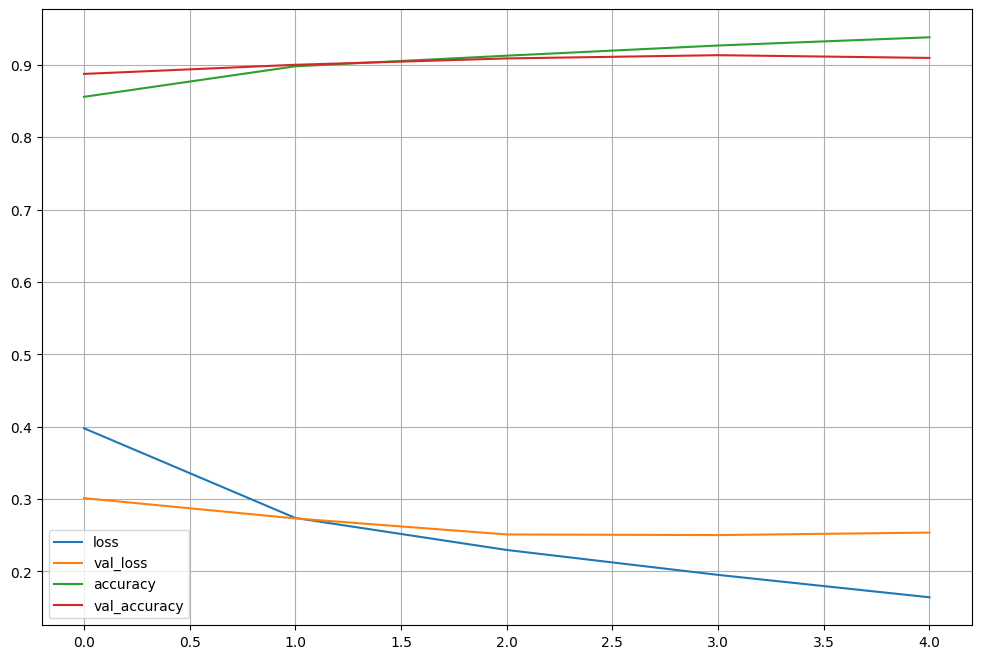

In [6]:
import matplotlib.pyplot as plt

plot_target = ["loss", "val_loss", "accuracy", "val_accuracy"]
plt.figure(figsize=(12, 8))

for each in plot_target:
    plt.plot(hist.history[each], label=each)

plt.legend()
plt.grid()
plt.show()

In [7]:
score = model.evaluate(X_test, y_test)
print("Test loss: ", score[0])
print("Testn accuracy: ", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9096 - loss: 0.2536
Test loss:  0.25355374813079834
Testn accuracy:  0.909600019454956


In [8]:
import numpy as np

predicted_result = model.predict(X_test)
predicted_labels = np.argmax(predicted_result, axis=1)
predicted_labels[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [9]:
wrong_result = []

for n in range(0, len(y_test)):
    if predicted_labels[n] != y_test[n]:
        wrong_result.append(n)

len(wrong_result)

904

In [10]:
import random

samples = random.choices(population=wrong_result, k=16)
samples

[7004,
 5006,
 4658,
 6402,
 8156,
 8317,
 4629,
 4206,
 921,
 3084,
 9349,
 6472,
 860,
 664,
 6127,
 4460]

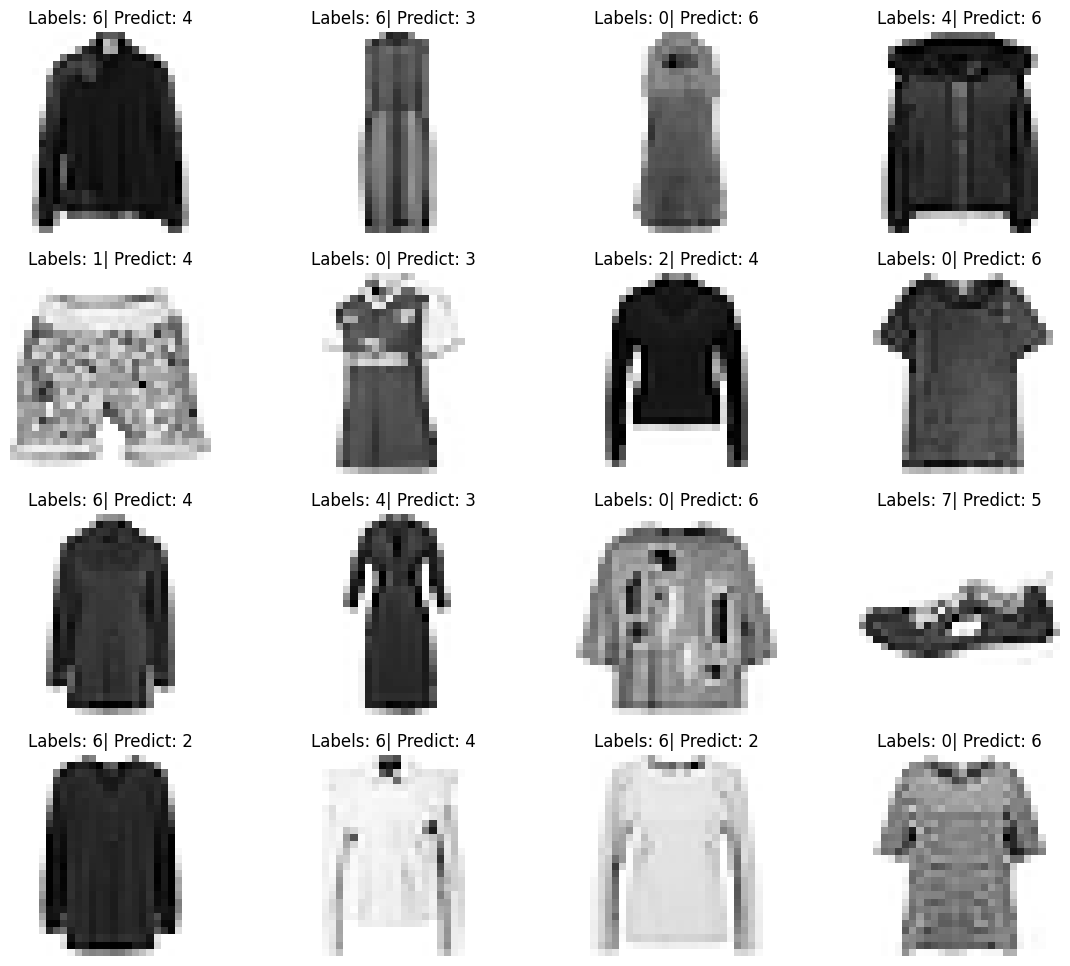

In [11]:
plt.figure(figsize=(14, 12))

for idx, n in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(X_test[n].reshape(28, 28), cmap="Greys")
    plt.title("Labels: " + str(y_test[n]) + "| Predict: " + str(predicted_labels[n]))
    plt.axis("off")

plt.show()

In [12]:
model.save("MNIST_CNN_model_fashion.keras")